# Exploratory Data Analysis: Jigsaw Agile Community Rules
This notebook performs a comprehensive analysis of the Jigsaw dataset to understand data structures, label distributions, and text characteristics for community rule violation detection.

## Data Acquisition
The dataset is retrieved directly from the Kaggle competition using the Kaggle API.

To reproduce this environment:
1. Upload your `kaggle.json` API token.
2. Run the following commands to download and extract the data:

```bash
# !pip install kaggle
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle competitions download -c jigsaw-agile-community-rules
# !unzip jigsaw-agile-community-rules.zip -d data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load datasets
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print(f"Train set shape: {train.shape}")
print(f"Test set shape: {test.shape}")

Train set shape: (2029, 9)
Test set shape: (10, 8)


### 1. Data Integrity and Quality
Checking for missing values and duplicates to ensure data quality before preprocessing.

In [4]:
# Check for missing values
print("Missing values in Train:\n", train.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows in Train: {train.duplicated().sum()}")

# Unique count of core entities
print("\nUnique entity counts:")
print(train[['subreddit', 'rule']].nunique())

Missing values in Train:
 row_id                0
body                  0
rule                  0
subreddit             0
positive_example_1    0
positive_example_2    0
negative_example_1    0
negative_example_2    0
rule_violation        0
dtype: int64

Duplicate rows in Train: 0

Unique entity counts:
subreddit    100
rule           2
dtype: int64


### 2. Label Distribution Analysis
Visualizing the balance of the target variable `rule_violation`. This helps in deciding if we need specific loss functions (like Weighted Cross Entropy) to handle class imbalance.

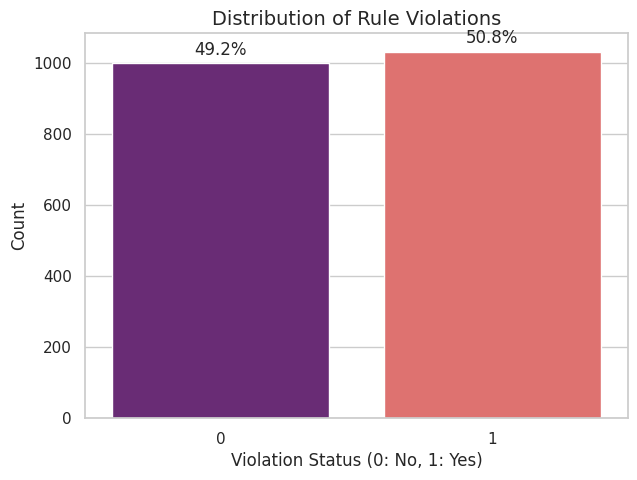

In [5]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='rule_violation', data=train, palette='magma')
plt.title('Distribution of Rule Violations', fontsize=14)
plt.xlabel('Violation Status (0: No, 1: Yes)')
plt.ylabel('Count')

# Add percentage annotations
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

### 3. Contextual Analysis: Subreddits and Rules
Analyzing which communities and rules have the highest violation rates to understand the context of the content.

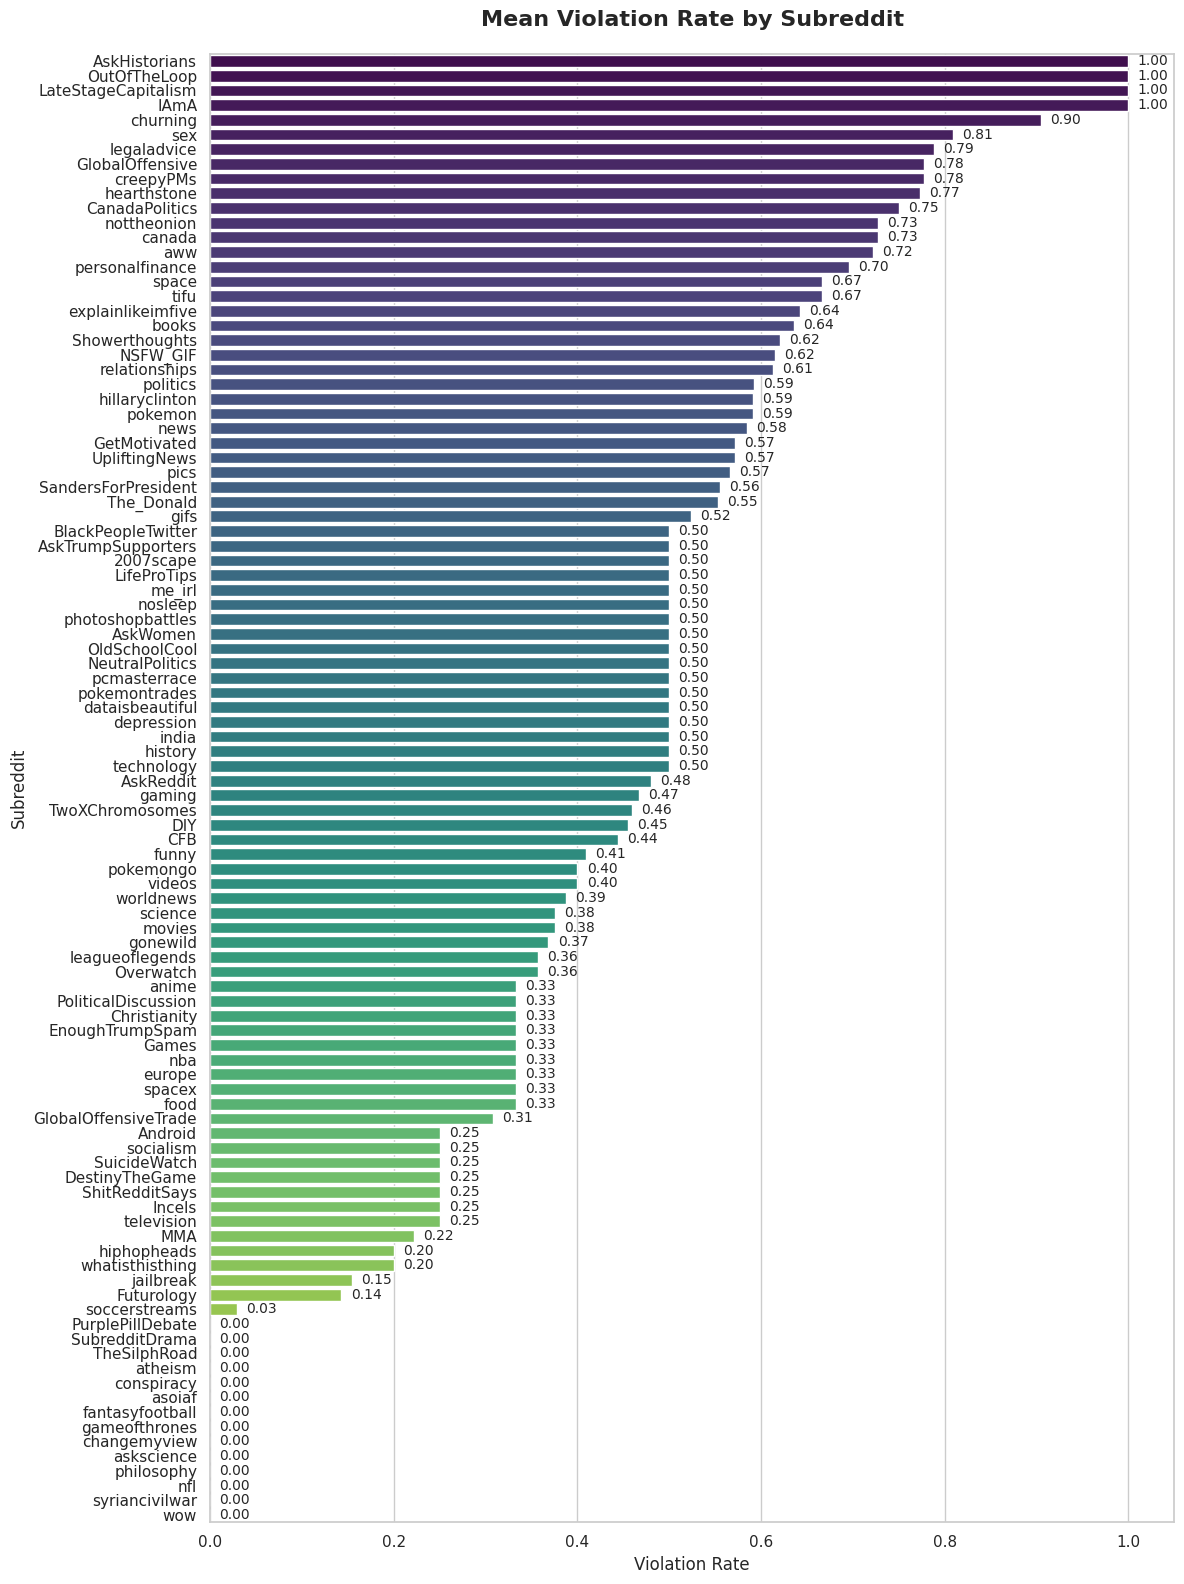

In [7]:
# Mean Violation Rate by Subreddit
plt.figure(figsize=(12, 16))
sns.barplot(x=sub_violation.values, y=sub_violation.index, palette='viridis')

plt.title('Mean Violation Rate by Subreddit', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Violation Rate', fontsize=12)
plt.ylabel('Subreddit', fontsize=12)

for i, v in enumerate(sub_violation.values):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 4. Sequence Length Analysis
Analyzing the number of tokens/words in `body` text. This insight is crucial for setting the `MAX_LEN` parameter in our Transformer models (DistilBERT).

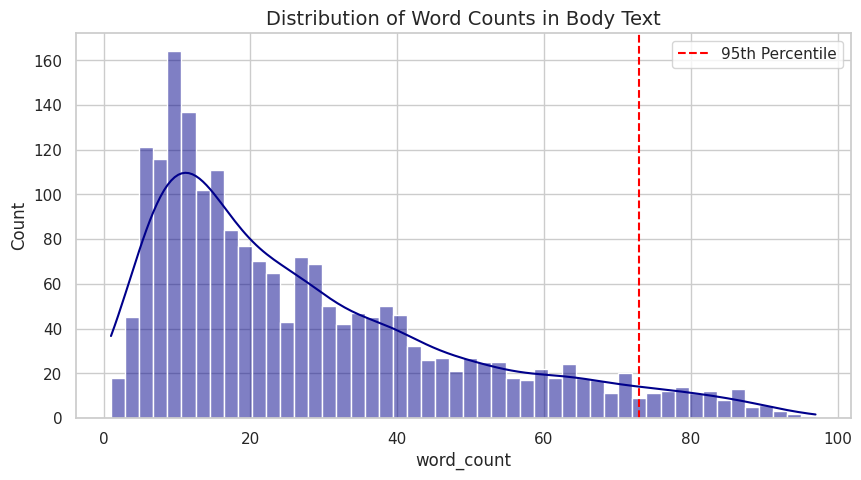

95% of texts are shorter than 73.0 words.


In [8]:
train['word_count'] = train['body'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(train['word_count'], bins=50, color='darkblue', kde=True)
plt.title('Distribution of Word Counts in Body Text', fontsize=14)
plt.axvline(train['word_count'].quantile(0.95), color='red', linestyle='--', label='95th Percentile')
plt.legend()
plt.show()

print(f"95% of texts are shorter than {train['word_count'].quantile(0.95)} words.")